# Versuchsaufbau (Aufgabe1)
Der Versuchsaufbau von Aufgabe 1 war einne aukustische Bank. Wo zwei Schieber mit einem Sender und Empfänger verschoben werden können. Der Sender ist mit einem Signalerzeuger verbunden, während der Empfänger mit dem Oszilloskop und dem Spannungsmesser verbunden war.
Für die verschiedenen Teilaufgaben in der 1ten Aufgabe wurde verschieden Vorgegangen.
b) Hierfür wurde für einen festen Abstand, für verschiedene Frequenzen die Amplitude über das Messgerät gemessen um herauszufinden wann die Amplitude der Frequenz am größten beim Empfänger ist. Die ermittelte Resonanzfrequenz wurde in allen anderen Versuchen dann benutzt.
c) Für c) wurde die Amplitude für eine feste Frequenz, der Empfänger immer weiter von dem Sender weggeschoben. Es wird eine $1/r$ abhängigkeit erwartet, wegen des kugelwellen Charakters der Schallwelle.
d) Es wurde für bestimmte Lissajous-Figuren, die eine gewisse Phasendifferenz beschreiben der Abstand zwischen Sender und Empfänger gemessen. Dabei war die Frequenz fest und nur der ABstadn wurde geändert.
e) FÜr die letzte Teilaufgabe in 1 wurde für eine feste Frequenz für verschiedene Abstände die Zeit gemessen, die das Signal vom Sender zum Empfänger braucht. Dabei wird die Schallgeschwindigkeit als geradlinige gleichmäßige Bewegung angenommen.

## Teilaufgabe b

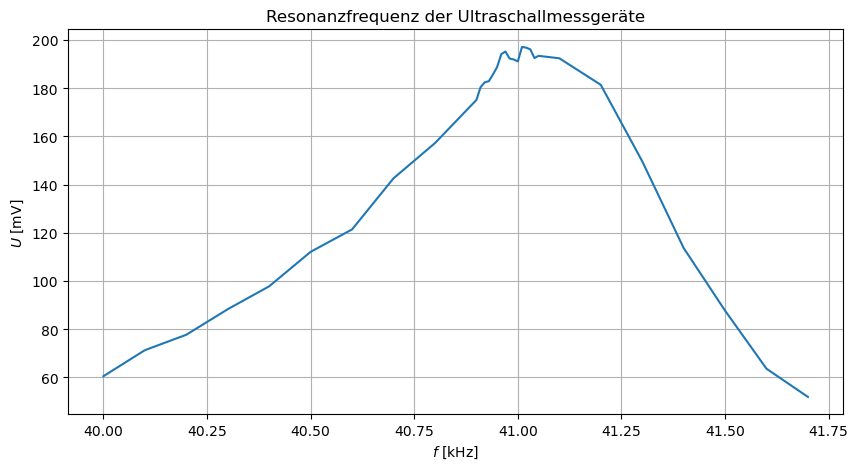

In [10]:
# | fig-cap: Resonanzfrequenz der Ultraschallmessgeräte
# | label: fig-resonanzfreq
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

daten = pd.read_csv("./daten/Aufgabe1b.csv")

frequenz = daten["f [kHz]"]
spannung = daten["U [mV]"]


plt.figure(figsize=(10,5))
plt.plot(frequenz, spannung)
plt.title("Resonanzfrequenz der Ultraschallmessgeräte")
plt.xlabel("$f$ [kHz]")
plt.ylabel("$U$ [mV]")
plt.grid()
plt.show()

## Teilaufgabe c


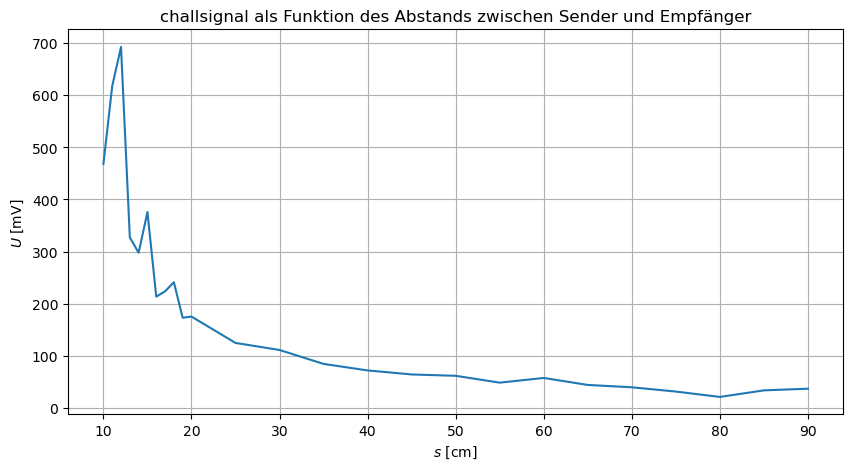

In [ ]:
# | fig-cap: Schallsignal als Funktion des Abstands zwischen Sender und Empfänger
# | label: fig-schallsignal-ueber-abstand
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

daten = pd.read_csv("./daten/Aufgabe1c.csv")

abstand = daten["s [cm]"]
spannung = daten["U [mV]"]

plt.figure(figsize=(10,5))
plt.plot(abstand, spannung)
plt.title("Schallsignal als Funktion des Abstands zwischen Sender und Empfänger")
plt.xlabel("$s$ [cm]")
plt.ylabel("$U$ [mV]")
plt.grid()
plt.show()

## Teilaufgabe d

In [17]:
import csv

#Konstanten:
frequenz = 41010  # Frequenz in Hz


with open('daten/Aufgabe1d.csv', newline='') as f:
    reader = csv.reader(f)
    data = list(reader)

data.remove(data[0])  # Remove header row
data = sorted(data, key=lambda x: float(x[0]))  # Sort by first column (distance)
print(data)

data_with_solutions = []



[['11.10', 'False'], ['11.50', 'True'], ['12', 'False'], ['19', 'True'], ['19.50', 'False'], ['20', 'True'], ['20.40', 'False'], ['25.10', 'True'], ['25.50', 'False'], ['34.80', 'False'], ['35.20', 'True'], ['45', 'False'], ['58.20', 'True']]


Beste Wellenlänge λ ≈ 0.0100 m
Schallgeschwindigkeit c ≈ 411.82 m/s
Bestimmte n-Werte: [0, 1, 2, 16, 17, 18, 19, 28, 29, 47, 48, 68, 94]


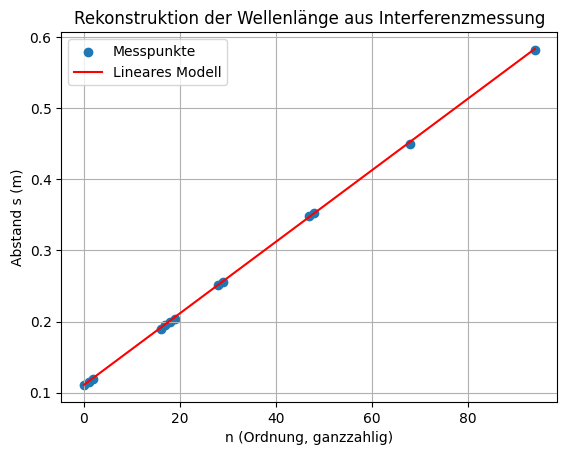

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

with open('daten/Aufgabe1d.csv', newline='') as f:
    reader = csv.reader(f)
    data = list(reader)

data.remove(data[0])  # Remove header row
data = sorted(data, key=lambda x: float(x[0]))  # Sort by first column (distance)

for i in range(len(data)):
    data[i][0] = 0.01*float(data[i][0])  # Convert first column to float (distance)

# Alle möglichen Kombinationen von (λ/2)-Schritten durchprobieren
best_lambda = None
min_error = float('inf')
best_n = None

for lambda_guess in np.linspace(0.01, 1.0, 1000):  # Wellenlängenbereich [1 cm – 1 m]
    half_lambda = lambda_guess / 2
    s0 = data[0][0]

    n_list = []
    s_list = []

    for s, _ in data:
        n = round((s - s0) / half_lambda)
        s_calc = s0 + n * half_lambda
        n_list.append(n)
        s_list.append(s)

    # Regressionsfehler berechnen
    model = LinearRegression().fit(np.array(n_list).reshape(-1, 1), s_list)
    s_pred = model.predict(np.array(n_list).reshape(-1, 1))
    error = np.mean((np.array(s_list) - s_pred) ** 2)

    if error < min_error:
        min_error = error
        best_lambda = 2 * model.coef_[0]
        best_n = n_list.copy()

# Frequenz einsetzen
f = 41010  # Hz
c = best_lambda * f

# Ausgabe
print(f"Beste Wellenlänge λ ≈ {best_lambda:.4f} m")
print(f"Schallgeschwindigkeit c ≈ {c:.2f} m/s")
print("Bestimmte n-Werte:", best_n)

# Plot
plt.scatter(best_n, s_list, label='Messpunkte')
plt.plot(best_n, [best_n[i] * best_lambda / 2 + data[0][0] for i in range(len(best_n))],
         color='red', label='Lineares Modell')
plt.xlabel("n (Ordnung, ganzzahlig)")
plt.ylabel("Abstand s (m)")
plt.title("Rekonstruktion der Wellenlänge aus Interferenzmessung")
plt.grid(True)
plt.legend()
plt.show()


## Teilaufgabe e

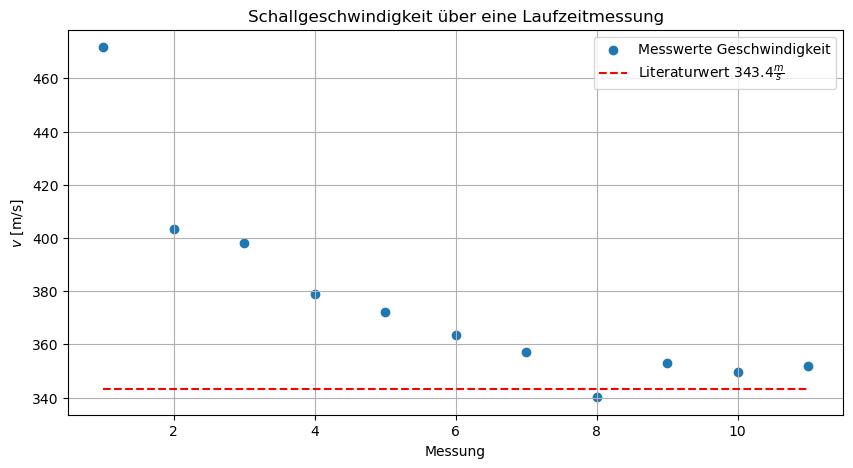

In [24]:
# | fig-cap: Schallgeschwindigkeit über eine Laufzeitmessung
# | label: fig-schallgesch-ueber-laufzeitmess
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

daten = pd.read_csv("./daten/Aufgabe1e.csv")

abstand = daten["s [cm]"] * 10^(-2)
zeit = daten["t [us]"] * 10^(-6)

gesch = daten["v [m/s]"]

plt.figure(figsize=(10,5))
plt.scatter(np.linspace(1, 11, 11), gesch, label="Messwerte Geschwindigkeit")
plt.hlines(343.4, xmin=1, xmax=len(abstand), colors='r', linestyles='--', label="Literaturwert $343.4 \\frac{m}{s}$")
plt.title("Schallgeschwindigkeit über eine Laufzeitmessung")
plt.xlabel("Messung")
plt.ylabel("$v$ [m/s]")
plt.legend()
plt.grid()
plt.show()